<a href="https://colab.research.google.com/github/GBharathG/Google-Play-Store-EDA/blob/main/Google_Play_Store_Analytics_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Uploading the Dataset

Run the next cell and upload **`googleplaystore.csv`**.

In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded file(s):", list(uploaded.keys()))

Saving googleplaystore.csv to googleplaystore.csv
Uploaded file(s): ['googleplaystore.csv']


## 3. Loading of Dataset

In [ ]:
import io

file_name = 'googleplaystore.csv'

if file_name in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
else:
    # Fallback if the uploaded filename differs
    actual_file = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[actual_file]))

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 4. Initial Data Inspection

In [ ]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic information:")
df.info()

Rows and columns: (10841, 13)

Column names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Data types:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## 5. Missing Values

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct.round(2)
})

display(missing_report[missing_report['Missing Values'] > 0])

,Missing Values,Missing %
Rating,1474,13.60
Current Ver,8,0.07
Android Ver,3,0.03
Content Rating,1,0.01
Type,1,0.01


## 6. Duplicate Check

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 483


## 7. Checking the Known Google Play Store Dataset Issue


In [ ]:
# Display rows where the Category is not one of the expected categories
print(df[df['Category'].astype(str).str.upper().str.contains('LIFE', na=False)])

# Show unique categories
print("\nNumber of unique categories before cleaning:", df['Category'].nunique())
print(df['Category'].unique())

                                                     App   Category  Rating  \
1562                          Dollhouse Decorating Games  LIFESTYLE     4.1   
1563                                           metroZONE  LIFESTYLE     4.1   
1564                              Easy Hair Style Design  LIFESTYLE     4.3   
1565                      Talking Babsy Baby: Baby Games  LIFESTYLE     4.0   
1566   Black Wallpaper, AMOLED, Dark Background: Darkify  LIFESTYLE     4.6   
...                                                  ...        ...     ...   
10773                                           FQ India  LIFESTYLE     NaN   
10797                              Fuel Rewards® program  LIFESTYLE     4.6   
10805                                      Scoreboard FR  LIFESTYLE     4.3   
10808                                 lesparticuliers.fr  LIFESTYLE     NaN   
10840      iHoroscope - 2018 Daily Horoscope & Astrology  LIFESTYLE     4.5   

      Reviews  Size     Installs  Type Price Conten

## 8. Data Cleaning

Cleaning performed:
- Standardize column names
- Remove exact duplicates
- Convert Rating, Reviews, Size, Installs and Price to numeric
- Convert Last Updated to datetime
- Clean Type and text columns
- Remove invalid/malformed records where required

For `Size`, values such as `Varies with device` are treated as missing because there is no numeric size available.

In [ ]:
# Work on a copy
clean_df = df.copy()

# Standardize column names
clean_df.columns = [c.strip() for c in clean_df.columns]

# Remove exact duplicate rows
clean_df = clean_df.drop_duplicates().copy()

# Clean text fields
text_columns = ['App', 'Category', 'Type', 'Content Rating', 'Genres',
                'Current Ver', 'Android Ver']

for col in text_columns:
    clean_df[col] = clean_df[col].astype('string').str.strip()

# Convert Rating
clean_df['Rating'] = pd.to_numeric(clean_df['Rating'], errors='coerce')

# Convert Reviews
clean_df['Reviews'] = pd.to_numeric(clean_df['Reviews'], errors='coerce')

# Clean Size
clean_df['Size'] = (
    clean_df['Size']
    .astype('string')
    .str.strip()
    .replace({'Varies with device': pd.NA})
)

clean_df['Size_MB'] = (
    clean_df['Size']
    .str.replace('M', '', regex=False)
    .str.replace('k', '', regex=False)
)

# Convert Size carefully: k means KB, M means MB.
def convert_size(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    try:
        if value.lower().endswith('m'):
            return float(value[:-1])
        if value.lower().endswith('k'):
            return float(value[:-1]) / 1024
        return float(value)
    except:
        return np.nan

clean_df['Size_MB'] = clean_df['Size'].apply(convert_size)

# Clean Installs
clean_df['Installs'] = (
    clean_df['Installs']
    .astype('string')
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .str.strip()
)

clean_df['Installs'] = pd.to_numeric(clean_df['Installs'], errors='coerce')

# Clean Price
clean_df['Price'] = (
    clean_df['Price']
    .astype('string')
    .str.replace('$', '', regex=False)
    .str.strip()
)

clean_df['Price'] = pd.to_numeric(clean_df['Price'], errors='coerce')

# Convert date
clean_df['Last Updated'] = pd.to_datetime(
    clean_df['Last Updated'],
    errors='coerce'
)

# Remove rows that are invalid for the core analysis
clean_df = clean_df[
    clean_df['App'].notna() &
    clean_df['Category'].notna()
].copy()

# Rating is missing for many apps, but we retain those rows for install/app-count analysis.
print("Cleaned shape:", clean_df.shape)
display(clean_df.head())

Cleaned shape: (10358, 14)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8


## 9. Validate Cleaned Data

In [ ]:
print("Data types after cleaning:")
print(clean_df.dtypes)

print("\nMissing values after cleaning:")
display(clean_df.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate rows after cleaning:", clean_df.duplicated().sum())

Data types after cleaning:
App               string[python]
Category          string[python]
Rating                   float64
Reviews                  float64
Size              string[python]
Installs                   Int64
Type              string[python]
Price                    Float64
Content Rating    string[python]
Genres            string[python]
Last Updated      datetime64[ns]
Current Ver       string[python]
Android Ver       string[python]
Size_MB                  float64
dtype: object

Missing values after cleaning:


,0
Size_MB,1527
Size,1526
Rating,1465
Current Ver,8
Android Ver,3
Reviews,1
Price,1
Content Rating,1
Installs,1
Type,1



Duplicate rows after cleaning: 0


## 10. Save Cleaned Dataset

In [ ]:
clean_df.to_csv('googleplaystore_cleaned.csv', index=False)

print("Saved: googleplaystore_cleaned.csv")

Saved: googleplaystore_cleaned.csv


# BASIC-LEVEL QUESTIONS

## Basic 1 — What is the average rating of apps?

In [ ]:
average_rating = clean_df['Rating'].mean()
print(f"Average app rating: {average_rating:.2f} / 5")

Average app rating: 4.19 / 5


## Basic 2 — How many unique app categories are there?

In [ ]:
unique_categories = clean_df['Category'].nunique()
print("Number of unique categories:", unique_categories)
print("\nCategories:")
print(sorted(clean_df['Category'].dropna().unique()))

Number of unique categories: 34

Categories:
['1.9', 'ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY', 'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION', 'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FAMILY', 'FINANCE', 'FOOD_AND_DRINK', 'GAME', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME', 'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'MAPS_AND_NAVIGATION', 'MEDICAL', 'NEWS_AND_MAGAZINES', 'PARENTING', 'PERSONALIZATION', 'PHOTOGRAPHY', 'PRODUCTIVITY', 'SHOPPING', 'SOCIAL', 'SPORTS', 'TOOLS', 'TRAVEL_AND_LOCAL', 'VIDEO_PLAYERS', 'WEATHER']


## Basic 3 — What is the distribution of app sizes?

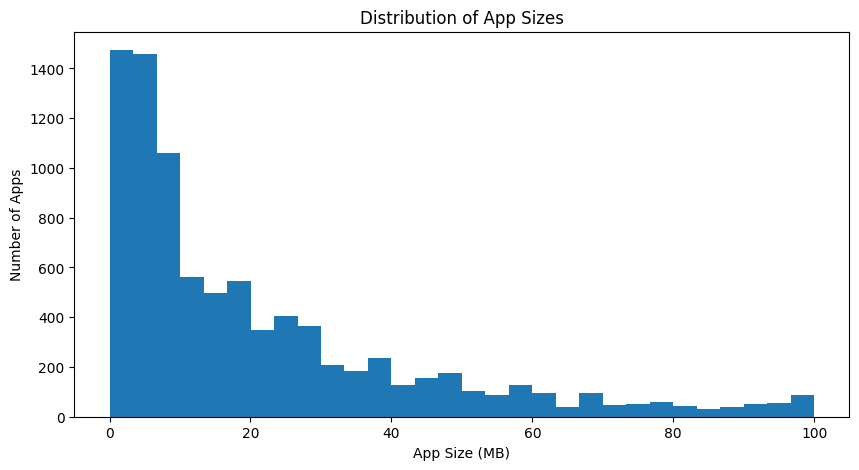

count    8831.000000
mean       21.287413
std        22.540591
min         0.008301
25%         4.700000
50%        13.000000
75%        29.000000
max       100.000000
Name: Size_MB, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(clean_df['Size_MB'].dropna(), bins=30)
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Apps')
plt.title('Distribution of App Sizes')
plt.show()

print(clean_df['Size_MB'].describe())

## Basic 4 — How many free vs paid apps are there?

,App Count
Type,
Free,9591
Paid,765
<NA>,1
0,1


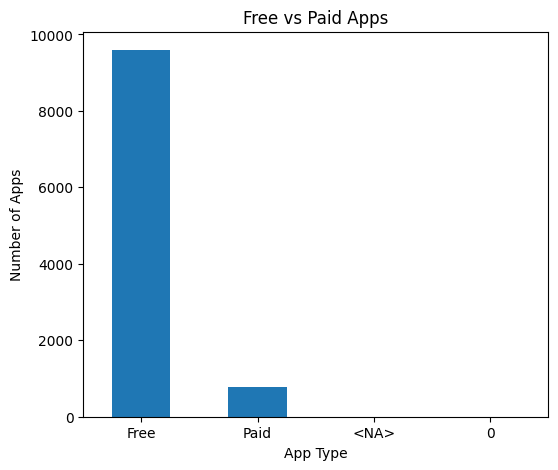

In [ ]:
type_counts = clean_df['Type'].value_counts(dropna=False)
display(type_counts.to_frame('App Count'))

plt.figure(figsize=(6, 5))
type_counts.plot(kind='bar')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.title('Free vs Paid Apps')
plt.xticks(rotation=0)
plt.show()

## Basic 5 — What is the most common content rating?

In [ ]:
content_mode = clean_df['Content Rating'].mode()[0]
content_counts = clean_df['Content Rating'].value_counts()

print("Most common content rating:", content_mode)
display(content_counts.to_frame('App Count'))

Most common content rating: Everyone


,App Count
Content Rating,
Everyone,8382
Teen,1146
Mature 17+,447
Everyone 10+,377
Adults only 18+,3
Unrated,2


## Basic 6 — What are the top 5 most installed apps?

In [ ]:
top5_installed = (
    clean_df[['App', 'Category', 'Installs', 'Rating']]
    .dropna(subset=['Installs'])
    .sort_values('Installs', ascending=False)
    .drop_duplicates(subset=['App'])
    .head(5)
)

display(top5_installed)

,App,Category,Installs,Rating
3454,Google Drive,PRODUCTIVITY,1000000000,4.4
865,Google Play Games,ENTERTAINMENT,1000000000,4.3
2544,Facebook,SOCIAL,1000000000,4.1
2545,Instagram,SOCIAL,1000000000,4.5
464,Hangouts,COMMUNICATION,1000000000,4.0


## Basic 7 — How many apps have a rating of 4.0 and above?

In [ ]:
high_rated_count = clean_df.loc[clean_df['Rating'] >= 4.0, 'App'].nunique()
print("Number of apps with rating >= 4.0:", high_rated_count)

Number of apps with rating >= 4.0: 6288


## Basic 8 — What is the average number of reviews for free vs paid apps?

In [ ]:
avg_reviews_by_type = (
    clean_df.groupby('Type', dropna=False)['Reviews']
    .mean()
    .sort_values(ascending=False)
)

display(avg_reviews_by_type.to_frame('Average Reviews'))

,Average Reviews
Type,
Free,437373.593056
Paid,11900.550327
<NA>,0.000000
0,NaN


## Basic 9 — What is the average app size for each category?

In [ ]:
avg_size_category = (
    clean_df.groupby('Category')['Size_MB']
    .mean()
    .sort_values(ascending=False)
)

display(avg_size_category.to_frame('Average Size (MB)'))

,Average Size (MB)
Category,
GAME,44.126816
FAMILY,27.930205
TRAVEL_AND_LOCAL,24.515960
SPORTS,24.180992
ENTERTAINMENT,22.638806
PARENTING,22.512963
FOOD_AND_DRINK,22.056122
HEALTH_AND_FITNESS,21.642819
EDUCATION,20.076632


## Basic 10 — How many apps were last updated in 2018?

In [ ]:
apps_updated_2018 = clean_df.loc[
    clean_df['Last Updated'].dt.year == 2018,
    'App'
].nunique()

print("Apps last updated in 2018:", apps_updated_2018)

Apps last updated in 2018: 6287


# MEDIUM-LEVEL QUESTIONS

## Medium 1 — What is the correlation between installs and rating?

In [ ]:
corr_data = clean_df[['Installs', 'Rating']].dropna()
correlation = corr_data['Installs'].corr(corr_data['Rating'])

print(f"Pearson correlation between Installs and Rating: {correlation:.4f}")

Pearson correlation between Installs and Rating: 0.0509


## Medium 2 — Which app categories have the highest average rating?

In [ ]:
category_rating = (
    clean_df.groupby('Category')
    .agg(
        Average_Rating=('Rating', 'mean'),
        App_Count=('App', 'nunique')
    )
    .sort_values('Average_Rating', ascending=False)
)

display(category_rating.head(10))

,Average_Rating,App_Count
Category,,
1.9,19.000000,1
EVENTS,4.435556,64
EDUCATION,4.375969,119
ART_AND_DESIGN,4.358065,64
BOOKS_AND_REFERENCE,4.347458,222
PERSONALIZATION,4.333871,376
PARENTING,4.300000,60
GAME,4.281285,960
BEAUTY,4.278571,53


## Medium 3 — How does app price affect average rating? (Paid apps only)

,Average_Rating,App_Count
Price,,
0.99,4.298095,145
1.0,4.450000,3
1.04,NaN,1
1.2,4.200000,1
1.26,NaN,1
1.29,4.100000,1
1.49,4.196774,46
1.5,4.200000,1
1.59,4.500000,1


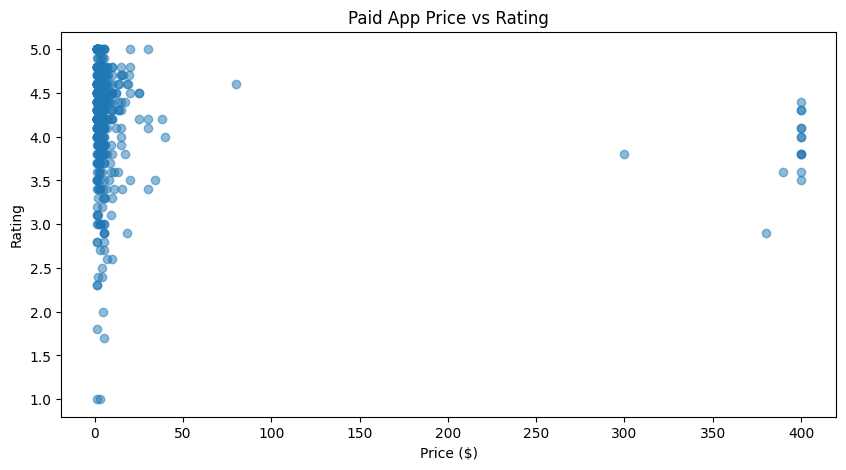

In [ ]:
paid_df = clean_df[clean_df['Type'].eq('Paid')].copy()

price_rating = (
    paid_df.groupby('Price')
    .agg(
        Average_Rating=('Rating', 'mean'),
        App_Count=('App', 'nunique')
    )
    .sort_index()
)

display(price_rating.head(30))

plt.figure(figsize=(10, 5))
plt.scatter(paid_df['Price'], paid_df['Rating'], alpha=0.5)
plt.xlabel('Price ($)')
plt.ylabel('Rating')
plt.title('Paid App Price vs Rating')
plt.show()

## Medium 4 — What is the distribution of ratings across content ratings?

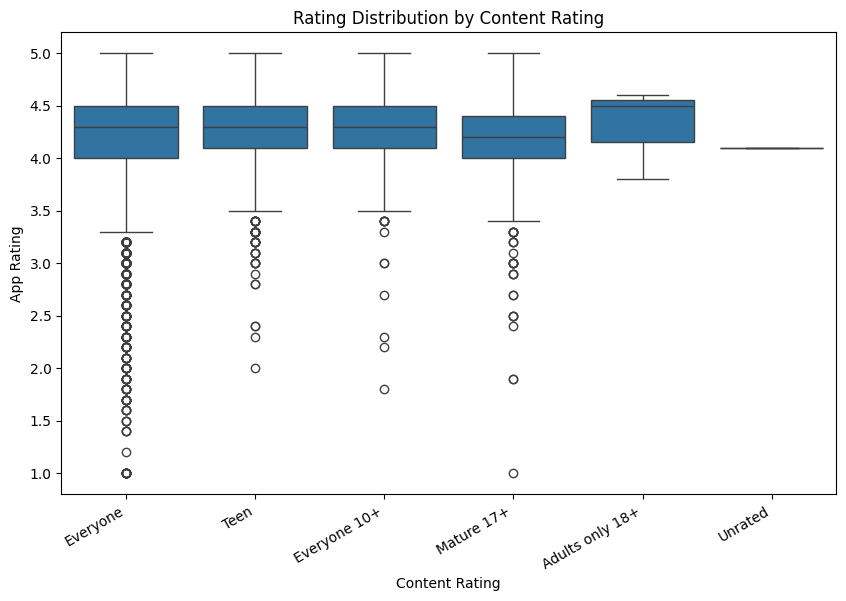

In [ ]:
box_data = clean_df.dropna(subset=['Rating', 'Content Rating'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=box_data, x='Content Rating', y='Rating')
plt.xlabel('Content Rating')
plt.ylabel('App Rating')
plt.title('Rating Distribution by Content Rating')
plt.xticks(rotation=30, ha='right')
plt.show()

## Medium 5 — Which genres have the most apps with over 1 million installs?

In [ ]:
over_1m = clean_df[clean_df['Installs'] > 1_000_000].copy()

genre_over_1m = (
    over_1m.groupby('Genres')['App']
    .nunique()
    .sort_values(ascending=False)
)

display(genre_over_1m.head(15).to_frame('Apps Over 1M Installs'))

,Apps Over 1M Installs
Genres,
Tools,173
Action,128
Photography,124
Communication,99
Productivity,91
Entertainment,83
Arcade,82
Sports,79
Shopping,72


## Medium 6 — How frequently do apps get updated?

**Dataset limitation:** The supplied Google Play Store Apps dataset has only one `Last Updated` value per app. It does not provide multiple update events for each app, so a true average time *between updates per app* cannot be calculated.

Instead, we analyze the distribution of the latest update dates and the number of apps updated by year/month.

,Apps Updated
Year,
2010,1
2011,15
2012,26
2013,108
2014,203
2015,451
2016,779
2017,1796
2018,6287


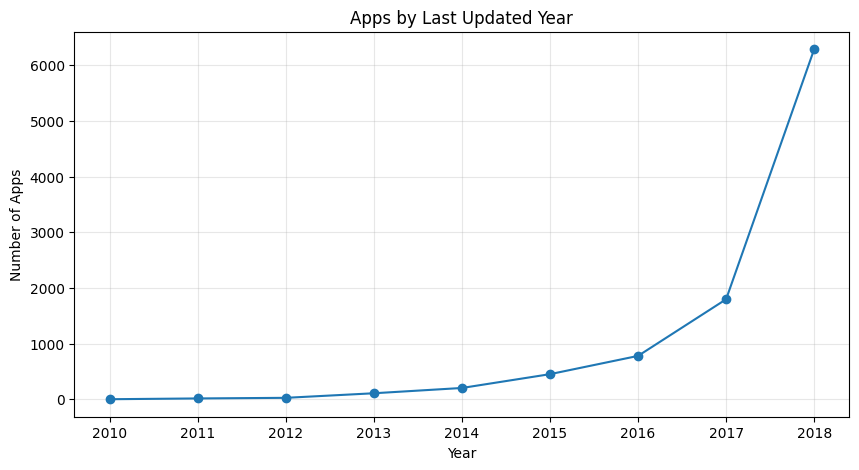

In [ ]:
update_by_year = (
    clean_df.dropna(subset=['Last Updated'])
    .assign(Year=lambda x: x['Last Updated'].dt.year)
    .groupby('Year')['App']
    .nunique()
)

display(update_by_year.to_frame('Apps Updated'))

plt.figure(figsize=(10, 5))
update_by_year.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Apps')
plt.title('Apps by Last Updated Year')
plt.grid(True, alpha=0.3)
plt.show()

## Medium 7 — What is the impact of app size on installs?

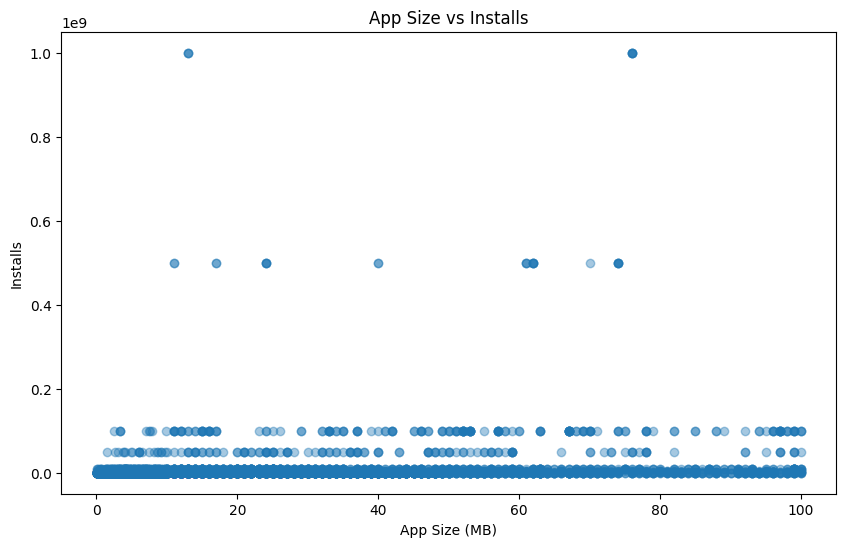

Correlation between Size and Installs: 0.16887201973119803


In [ ]:
size_install = clean_df[['Size_MB', 'Installs']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(size_install['Size_MB'], size_install['Installs'], alpha=0.4)
plt.xlabel('App Size (MB)')
plt.ylabel('Installs')
plt.title('App Size vs Installs')
plt.show()

print("Correlation between Size and Installs:",
      size_install['Size_MB'].corr(size_install['Installs']))

## Medium 8 — Which apps have the highest number of reviews, and what are their ratings?

In [ ]:
top_reviewed = (
    clean_df[['App', 'Category', 'Reviews', 'Rating', 'Installs']]
    .dropna(subset=['Reviews'])
    .sort_values('Reviews', ascending=False)
    .drop_duplicates(subset=['App'])
    .head(10)
)

display(top_reviewed)

,App,Category,Reviews,Rating,Installs
2544,Facebook,SOCIAL,78158306.0,4.1,1000000000
336,WhatsApp Messenger,COMMUNICATION,69119316.0,4.4,1000000000
2604,Instagram,SOCIAL,66577446.0,4.5,1000000000
382,Messenger – Text and Video Chat for Free,COMMUNICATION,56646578.0,4.0,1000000000
1879,Clash of Clans,GAME,44893888.0,4.6,100000000
4005,Clean Master- Space Cleaner & Antivirus,TOOLS,42916526.0,4.7,500000000
1872,Subway Surfers,GAME,27725352.0,4.5,1000000000
3665,YouTube,VIDEO_PLAYERS,25655305.0,4.3,1000000000
7536,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,24900999.0,4.7,500000000
1878,Clash Royale,GAME,23136735.0,4.6,100000000


## Medium 9 — How does content rating distribution differ between free and paid apps?

Type,Free,Paid
Content Rating,,
Adults only 18+,3,0
Everyone,7720,662
Everyone 10+,344,32
Mature 17+,428,19
Teen,1094,52
Unrated,2,0


<Figure size 1000x600 with 0 Axes>

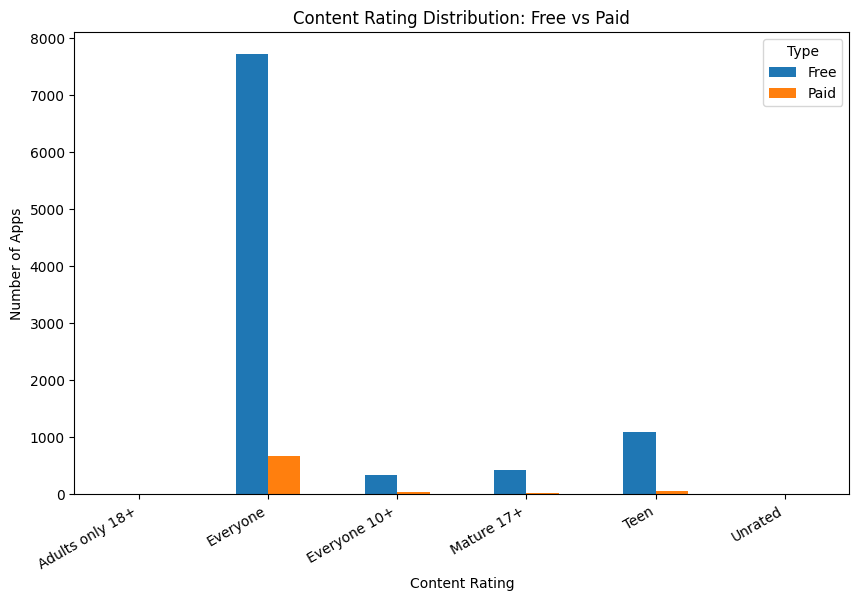

In [ ]:
content_type_crosstab = pd.crosstab(
    clean_df['Content Rating'],
    clean_df['Type']
)

display(content_type_crosstab)

plt.figure(figsize=(10, 6))
content_type_crosstab.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.title('Content Rating Distribution: Free vs Paid')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Type')
plt.show()

## Medium 10 — What are the top 5 categories with the most installs?

,Total Installs
Category,
GAME,31544024415
COMMUNICATION,24152276251
SOCIAL,12513867902
PRODUCTIVITY,12463091369
TOOLS,11452771915


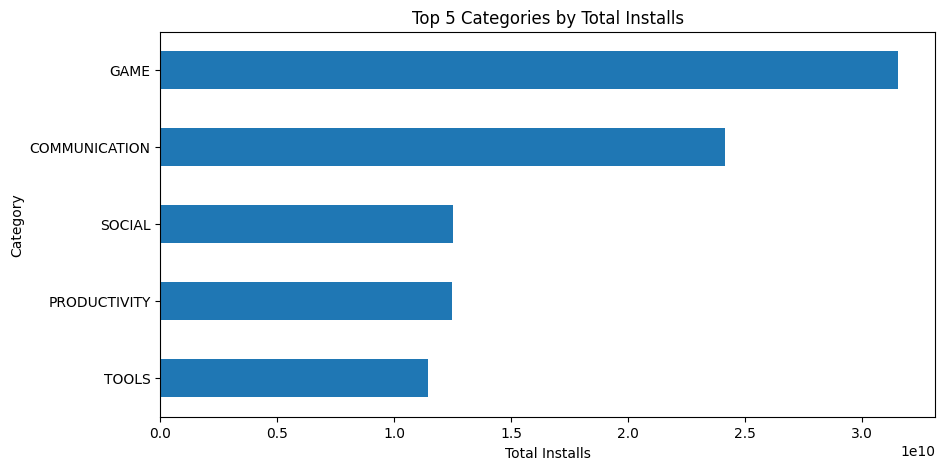

In [ ]:
category_installs = (
    clean_df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
)

top5_categories_installs = category_installs.head(5)
display(top5_categories_installs.to_frame('Total Installs'))

plt.figure(figsize=(10, 5))
top5_categories_installs.sort_values().plot(kind='barh')
plt.xlabel('Total Installs')
plt.ylabel('Category')
plt.title('Top 5 Categories by Total Installs')
plt.show()

# ADVANCED-LEVEL QUESTIONS

## Advanced 1 — Top 10 highest-rated apps and comparison with reviews and installs



In [ ]:
top10_rated_raw = (
    clean_df[['App', 'Category', 'Rating', 'Reviews', 'Installs']]
    .dropna(subset=['Rating'])
    .sort_values(['Rating', 'Reviews'], ascending=[False, False])
    .drop_duplicates(subset=['App'])
    .head(10)
)

print("Top 10 by rating:")
display(top10_rated_raw)

# More robust comparison: minimum 100 reviews
top10_rated_100 = (
    clean_df[
        clean_df['Rating'].notna() &
        (clean_df['Reviews'] >= 100)
    ][['App', 'Category', 'Rating', 'Reviews', 'Installs']]
    .sort_values(['Rating', 'Reviews'], ascending=[False, False])
    .drop_duplicates(subset=['App'])
    .head(10)
)

print("\nTop 10 rated apps with at least 100 reviews:")
display(top10_rated_100)

Top 10 by rating:


,App,Category,Rating,Reviews,Installs
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,<NA>
10357,Ríos de Fe,LIFESTYLE,5.0,141.0,1000
10301,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",FINANCE,5.0,104.0,1000
8058,Oración CX,LIFESTYLE,5.0,103.0,5000
6823,Barisal University App-BU Face,FAMILY,5.0,100.0,1000
9496,Master E.K,FAMILY,5.0,90.0,1000
7506,CL REPL,TOOLS,5.0,47.0,1000
5230,AJ Cam,PHOTOGRAPHY,5.0,44.0,100
5196,AI Today : Artificial Intelligence News & AI 101,NEWS_AND_MAGAZINES,5.0,43.0,100
7842,CS & IT Interview Questions,FAMILY,5.0,43.0,1000



Top 10 rated apps with at least 100 reviews:


,App,Category,Rating,Reviews,Installs
10357,Ríos de Fe,LIFESTYLE,5.0,141.0,1000
10301,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",FINANCE,5.0,104.0,1000
8058,Oración CX,LIFESTYLE,5.0,103.0,5000
6823,Barisal University App-BU Face,FAMILY,5.0,100.0,1000
9625,JW Library,BOOKS_AND_REFERENCE,4.9,922752.0,10000000
1260,Six Pack in 30 Days - Abs Workout,HEALTH_AND_FITNESS,4.9,272337.0,10000000
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,197136.0,1000000
712,"Learn Japanese, Korean, Chinese Offline & Free",EDUCATION,4.9,133136.0,1000000
2344,Period Tracker,MEDICAL,4.9,100082.0,1000000
1307,StrongLifts 5x5 Workout Gym Log & Personal Tra...,HEALTH_AND_FITNESS,4.9,66791.0,1000000


## Advanced 2 — Trend of app updates over time

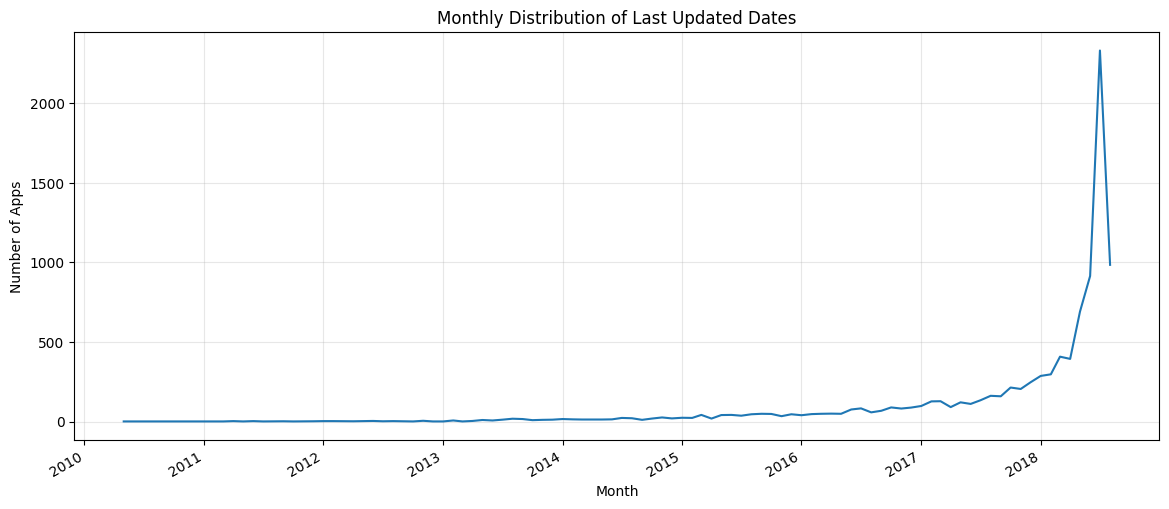

Peak update month:
2018-07-01 00:00:00 with 2332 apps


In [ ]:
monthly_updates = (
    clean_df.dropna(subset=['Last Updated'])
    .assign(Month=lambda x: x['Last Updated'].dt.to_period('M').dt.to_timestamp())
    .groupby('Month')['App']
    .nunique()
)

plt.figure(figsize=(14, 6))
monthly_updates.plot()
plt.xlabel('Month')
plt.ylabel('Number of Apps')
plt.title('Monthly Distribution of Last Updated Dates')
plt.grid(True, alpha=0.3)
plt.show()

print("Peak update month:")
print(monthly_updates.idxmax(), "with", monthly_updates.max(), "apps")

## Advanced 3 — How does average rating change with number of installs?

,Average_Rating,Median_Rating,App_Count
Install_Band,,,
0–10K,4.112427,4.3,2749
10K–100K,4.094593,4.2,1554
100K–1M,4.207043,4.3,1922
1M–10M,4.285675,4.3,1546
10M–100M,4.382995,4.4,393
100M+,4.309091,4.3,44


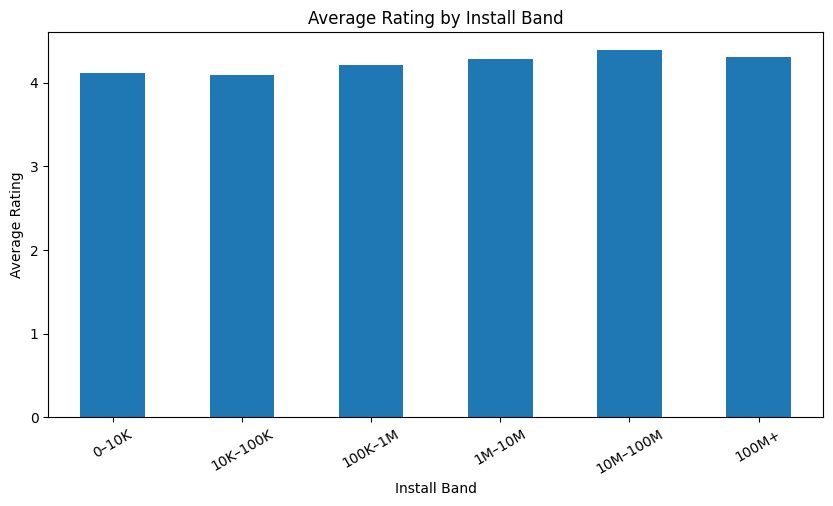

In [ ]:
bins = [0, 10_000, 100_000, 1_000_000, 10_000_000,
        100_000_000, np.inf]

labels = [
    '0–10K',
    '10K–100K',
    '100K–1M',
    '1M–10M',
    '10M–100M',
    '100M+'
]

binned_df = clean_df.dropna(subset=['Installs', 'Rating']).copy()

binned_df['Install_Band'] = pd.cut(
    binned_df['Installs'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

install_rating_analysis = (
    binned_df.groupby('Install_Band', observed=False)
    .agg(
        Average_Rating=('Rating', 'mean'),
        Median_Rating=('Rating', 'median'),
        App_Count=('App', 'nunique')
    )
)

display(install_rating_analysis)

plt.figure(figsize=(10, 5))
install_rating_analysis['Average_Rating'].plot(kind='bar')
plt.xlabel('Install Band')
plt.ylabel('Average Rating')
plt.title('Average Rating by Install Band')
plt.xticks(rotation=30)
plt.show()

## Advanced 4 — Sentiment analysis of app reviews

**Cannot be completed from the supplied `googleplaystore.csv` alone.**

The case study asks for review-text sentiment analysis, but the listed dataset fields contain the number of reviews (`Reviews`), not the actual review text. A separate Google Play Store Reviews dataset would be required.

No fabricated sentiment result is produced here.

In [ ]:
print("Sentiment analysis status:")
print("NOT PERFORMED — review text is not available in the supplied app dataset.")

Sentiment analysis status:
NOT PERFORMED — review text is not available in the supplied app dataset.


## Advanced 5 — Relationship between genre and user ratings

In [ ]:
genre_rating = (
    clean_df.groupby('Genres')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Median_Rating=('Rating', 'median'),
        App_Count=('App', 'nunique')
    )
    .sort_values('Average_Rating', ascending=False)
)

display(genre_rating.head(20))

print("\nLowest-rated genres:")
display(genre_rating.sort_values('Average_Rating').head(20))

,Average_Rating,Median_Rating,App_Count
Genres,,,
"February 11, 2018",19.000000,19.0,1
Board;Pretend Play,4.800000,4.8,1
Comics;Creativity,4.800000,4.8,1
Health & Fitness;Education,4.700000,4.7,1
Puzzle;Education,4.600000,4.6,1
Strategy;Action & Adventure,4.600000,4.6,2
Adventure;Brain Games,4.600000,4.6,1
Entertainment;Creativity,4.533333,4.6,3
Music;Music & Video,4.533333,4.6,3



Lowest-rated genres:


,Average_Rating,Median_Rating,App_Count
Genres,,,
Parenting;Brain Games,3.800000,3.80,1
Parenting;Education,3.866667,3.90,7
Educational,3.871875,3.95,37
Art & Design;Pretend Play,3.900000,3.90,1
Health & Fitness;Action & Adventure,3.900000,3.90,1
Educational;Creativity,3.960000,4.20,5
Dating,3.971698,4.10,171
Lifestyle;Pretend Play,4.000000,4.00,1
Video Players & Editors;Music & Video,4.000000,4.00,2


# ADDITIONAL BUSINESS ANALYSIS

## 11. Category Performance Summary

In [ ]:
category_summary = (
    clean_df.groupby('Category')
    .agg(
        Apps=('App', 'nunique'),
        Average_Rating=('Rating', 'mean'),
        Total_Reviews=('Reviews', 'sum'),
        Total_Installs=('Installs', 'sum'),
        Average_Size_MB=('Size_MB', 'mean')
    )
    .sort_values('Total_Installs', ascending=False)
)

display(category_summary.head(15))

,Apps,Average_Rating,Total_Reviews,Total_Installs,Average_Size_MB
Category,,,,,
GAME,960,4.281285,1.415537e+09,31544024415,44.126816
COMMUNICATION,316,4.151466,6.012736e+08,24152276251,11.657320
SOCIAL,239,4.254918,5.335768e+08,12513867902,16.875621
PRODUCTIVITY,374,4.201796,1.025545e+08,12463091369,12.871599
TOOLS,829,4.047411,2.731850e+08,11452771915,8.770335
FAMILY,1909,4.191153,3.967720e+08,10041692505,27.930205
PHOTOGRAPHY,281,4.182895,2.042974e+08,9721247655,16.831950
TRAVEL_AND_LOCAL,219,4.094146,5.556516e+07,6361887146,24.515960
VIDEO_PLAYERS,164,4.063750,1.103802e+08,6222002720,16.084441


## 12. Free vs Paid Performance Summary

In [ ]:
type_summary = (
    clean_df.groupby('Type')
    .agg(
        Apps=('App', 'nunique'),
        Average_Rating=('Rating', 'mean'),
        Average_Reviews=('Reviews', 'mean'),
        Total_Installs=('Installs', 'sum'),
        Average_Price=('Price', 'mean')
    )
)

display(type_summary)

,Apps,Average_Rating,Average_Reviews,Total_Installs,Average_Price
Type,,,,,
0,1,19.000000,NaN,0,<NA>
Free,8904,4.182425,437373.593056,146562688646,0.0
Paid,756,4.261501,11900.550327,69225881,13.955556


## 13. Top Categories by Average Rating — With Minimum App Count

This avoids ranking categories based on only one or two apps.

In [ ]:
category_quality = (
    clean_df.groupby('Category')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Apps_With_Rating=('Rating', 'count'),
        Total_Installs=('Installs', 'sum')
    )
)

category_quality_filtered = (
    category_quality[category_quality['Apps_With_Rating'] >= 10]
    .sort_values('Average_Rating', ascending=False)
)

display(category_quality_filtered.head(10))

,Average_Rating,Apps_With_Rating,Total_Installs
Category,,,
EVENTS,4.435556,45,15973161
EDUCATION,4.375969,129,533952000
ART_AND_DESIGN,4.358065,62,124338100
BOOKS_AND_REFERENCE,4.347458,177,1916469576
PERSONALIZATION,4.333871,310,2074494782
PARENTING,4.300000,50,31521110
GAME,4.281285,1074,31544024415
BEAUTY,4.278571,42,27197050
HEALTH_AND_FITNESS,4.261450,262,1361022512


## 14. Creating an Analysis Dataset for Power BI


In [ ]:
powerbi_df = clean_df.copy()

powerbi_df['Update Year'] = powerbi_df['Last Updated'].dt.year
powerbi_df['Update Month'] = powerbi_df['Last Updated'].dt.month
powerbi_df['Update Month Name'] = powerbi_df['Last Updated'].dt.month_name()
powerbi_df['Install Band'] = pd.cut(
    powerbi_df['Installs'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

powerbi_df['High Rated'] = np.where(
    powerbi_df['Rating'] >= 4.0,
    '4.0+',
    '<4.0'
)

powerbi_df['Paid/Free'] = powerbi_df['Type']

powerbi_df.to_csv('googleplaystore_powerbi.csv', index=False)

print("Created file: googleplaystore_powerbi.csv")
print("Rows:", len(powerbi_df))
display(powerbi_df.head())

Created file: googleplaystore_powerbi.csv
Rows: 10358


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update Year,Update Month,Update Month Name,Install Band,High Rated,Paid/Free
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,2018.0,1.0,January,0–10K,4.0+,Free
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,2018.0,1.0,January,100K–1M,<4.0,Free
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,2018.0,8.0,August,1M–10M,4.0+,Free
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,2018.0,6.0,June,10M–100M,4.0+,Free
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,2018.0,6.0,June,10K–100K,4.0+,Free
